# Model Development Notebook

###### Author: Shaurya Agarwal

###### Contact Me: realshauryaagarwal@proton.me

For the reference on how the datasets were compiled, refer to my previous notebook.
The data I am using here has been annotated by me.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import unicodedata
import os
import shutil
import pandas as pd
import numpy as np
import json
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import torchvision.transforms.functional as F
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from Trainer import CRNNTrainer
import random

SEED = 1628

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)
shutil.rmtree('runs') if os.path.exists('runs') else None
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


There is no deterministic implementation of CTC Loss in PyTorch. So, we are forced to use an algorithm which might give slightly different results

In [3]:
BLANK_IDX = 78

In [4]:

class OCRDataset(Dataset):
    def __init__(self, image_dir, label_path, tokeniser, transform=None):
        self.image_dir = image_dir
        self.df = pd.read_csv(label_path, header=None, names=["image", "label"], encoding='utf-8', keep_default_na=False)
        with open(tokeniser, 'r', encoding='utf-8') as f:
            self.char_to_idx = json.load(f)
        self.transform = transform
        
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image"]
        label = self.df.iloc[idx]["label"]
            
        if not isinstance(label, str):
            print("Image path:", img_name)
            raise ValueError(f"Label at index {idx} is not a string: {label}")
        
        label = unicodedata.normalize("NFC", label)
        label = [self.char_to_idx.get(i, -1) for i in label]
        
        for loc, x in enumerate(label):
            if x == -1:
                raise ValueError(f"Unrecognized character at {loc} in label '{self.df.iloc[idx]['label']}' at index {idx}")
        
        img_path = os.path.join(self.image_dir, img_name + ".jpeg")

        image = Image.open(img_path).convert("L")  # grayscale

        if self.transform:
            image = self.transform(image)
        
        return image, label
 
class ResizeWithPadding:
    def __init__(self, height=32, max_width=128):
        self.height = height
        self.max_width = max_width

    def __call__(self, img):
        w, h = img.size

        # scale width according to new height
        new_w = int(w * (self.height / h))
        img = F.resize(img, (self.height, new_w))

        # pad or clamp
        if new_w < self.max_width:
            pad_width = self.max_width - new_w
            img = F.pad(img, (0, 0, pad_width, 0), fill=255)
        else:
            img = F.resize(img, (self.height, self.max_width))

        return img

In [5]:
def compute_max_width(image_dir, label_path, target_height=32, percentile=95):
    df = pd.read_csv(label_path, header=None, names=["image", "label"])

    widths = []

    for img_name in df["image"]:
        path = os.path.join(image_dir, img_name + ".jpeg")
        with Image.open(path) as img:
            w, h = img.size
            new_w = int(w * (target_height / h))
            widths.append(new_w)

    widths = np.array(widths)
    max_width = int(np.percentile(widths, percentile))

    print(f"Max_width = {max_width} (p{percentile})")
    return max_width
compute_max_width(r".\final_dataset\images", r".\final_dataset\labels.csv")

Max_width = 131 (p95)


131

In [6]:
def custom_collate_fn(batch):
    imgs, labels = zip(*batch)

    imgs = torch.stack(imgs, dim=0)  # [B, 1, H, W]

    labels = [torch.tensor(l, dtype=torch.long) for l in labels]

    target_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)

    targets = torch.cat(labels)  # 1D tensor

    _, _, _, W = imgs.shape
    input_lengths = torch.full(
        size=(len(imgs),),
        fill_value=W // 2,
        dtype=torch.long
    )

    return imgs, targets, input_lengths, target_lengths

In [7]:
transform = v2.Compose([
    ResizeWithPadding(height=32, max_width=128),
    v2.ToTensor()
])
dataset = OCRDataset(
    image_dir='./final_dataset/images',
    label_path='./final_dataset/labels.csv',
    tokeniser='./new_tokeniser.json',
    transform=transform
    )
idx_to_label = {v: k for k, v in dataset.char_to_idx.items()}
idx_to_label[BLANK_IDX] = ''
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.75, 0.2, 0.05])

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=(device == 'cuda'),
    collate_fn = custom_collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device == 'cuda'),
    collate_fn = custom_collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device == 'cuda'),
    collate_fn = custom_collate_fn
)

We can't use num_workers>0 on Windows.

In [8]:
if __name__ == "__main__":
    sum_ = 0
    sum_sq = 0
    total_pixels = 0

    transform = v2.Compose([
        ResizeWithPadding(height=32, max_width=128),
        v2.ToTensor()
    ])
    dataset.transform = transform

    for imgs, _, _, _ in train_loader:
        sum_ += imgs.sum(dim=(0, 2, 3)) 
        sum_sq += (imgs ** 2).sum(dim=(0, 2, 3))
        total_pixels += imgs.size(0) * imgs.size(2) * imgs.size(3)

    mean = sum_ / total_pixels
    std = torch.sqrt(sum_sq / total_pixels - mean ** 2)

    print(f"Mean: {mean.item()}")
    print(f"Standard Deviation: {std.item()}")
    print("Image dimensions used: (32, 128)")
    print("")


    transform = v2.Compose([
        ResizeWithPadding(height=32, max_width=128),
        v2.ToTensor(),
        v2.GaussianNoise(mean = 0, sigma = 0.05),
        v2.RandomRotation(degrees = 6, fill = 1),
        v2.Normalize(mean=mean, std=std)
    ])
    dataset.transform = transform


    print(f"Dataset size: {len(dataset)}")
    print("Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
    train_iter=iter(train_loader)
    images, labels, _, target_lengths = next(train_iter)
    print("Batch image tensor shape:", images.shape)

Mean: 0.8477857112884521
Standard Deviation: 0.24946823716163635
Image dimensions used: (32, 128)

Dataset size: 7396
Train/Val/Test sizes: 5548 1479 369
Batch image tensor shape: torch.Size([64, 1, 32, 128])


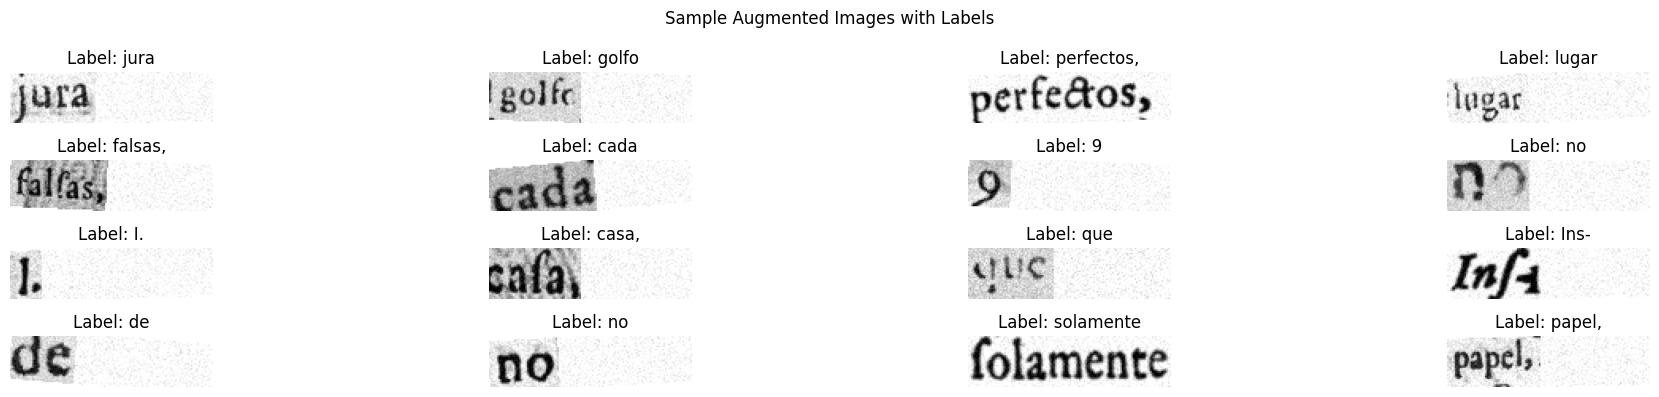

In [9]:
def imshow(imgs, labels, target_lengths, cols = 4, title = None):
    imgs = imgs * std + mean
    imgs = imgs.numpy()
    
    rows = imgs.shape[0] // cols + imgs.shape[0] % cols
    fig, ax = plt.subplots(rows, cols, figsize=(20, 1 * rows))
    if title:
        fig.suptitle(title)
    counter = 0
    for i in range(rows):
        for j in range(cols):
             ax[i, j].imshow(imgs[i * cols + j][0], cmap='gray')
             ax[i, j].axis('off')
             ax[i, j].set_title(f"Label: {''.join([idx_to_label[idx.item()] for idx in labels[counter:counter+target_lengths[i * cols + j]]])}")
             counter += target_lengths[i * cols + j]
    plt.axis('off')
    plt.tight_layout()
    plt.show()
imshow(images[:16], labels[:sum(target_lengths[:16])], target_lengths[:16], title="Sample Augmented Images with Labels")

In [10]:
class CRNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding='same', bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same', bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same', bias=False)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding='same', bias=False)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d((2, 1), (2, 1))
                
        self.embedding = nn.Linear(128 * 8, 256)
        self.ln = nn.LayerNorm(256)
        
        
        self.lstm = nn.LSTM(256, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = F_nn.leaky_relu(self.bn1(self.conv1(x)))
        x = F_nn.leaky_relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        x = F_nn.leaky_relu(self.bn3(self.conv3(x)))
        x = F_nn.leaky_relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        B, C, H, W = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(B, W, C * H)
        x = self.ln(self.embedding(x))
        x, _ = self.lstm(x)
        x = self.dropout(x)
        x = self.fc(x)
        x = x.permute(1, 0, 2)
        x = F_nn.log_softmax(x, dim=2)
        return x

### Some notes on the model
1. I saw a few Spanish language specific constraints mentioned like u and v were equivalent. However, as my tokeniser clearly shows, these characters are separately identified in the transcripts. I am unsure of what to do about this and have therefore simply segmented them into separate classes. This should not be that big of a problem. Naturally, improvements can be gained by limiting the number of classes, but then I don't know why there are differentiated letters in the transcript. I am assuming that this differentiation, although useless in the language's context, is to be preserved for some reason.
2. I have separated capital and small letters and preserved punctuations to the best of my ability. If these can be ignored, model performance can be improved.
3. The training was not optimised for speed, but rather for montoring. One can clearly see in the Trainer class the various attributes tracked. Moreover, the training loss is not per epoch, but per batch. Validation metrics are on the entire set and are consistent across steps (besides the random noise and rotation transformations). In this case of training, WER is equivalent to 1-word level accuracy, which means the percentage of words predicted exactly correct. 
4. I have use CTC Loss as the loss function for training. Even though it is very complicated, I believe it is the best for a sequence modeling task like transcription.


I also had a lot more ideas that I wanted to implement like fine-tuning the CRAFT model or exploring alternatives, *synthetic data augmentation*, beam search, attention, frequency weighted loss adjustment, line level OCR instead of word level OCR and of course deep Gemini integration. I could not implement any of these because the submission dates are approaching and I wanted to submit a week before then as advised in the test descriptions.

In [11]:
num_classes = len(dataset.char_to_idx) + 1  # +1 for CTC blank token
model = CRNNModel(num_classes=num_classes).to(device)
trainer = CRNNTrainer(model, train_loader, val_loader, BLANK_IDX, idx_to_label, device)
train_losses, val_losses = trainer.train(100)
torch.save(model.state_dict(), "CRNNmodel.pth")
print("Training complete and model saved as CRNNmodel.pth")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done
Epoch 11 done
Epoch 12 done
Epoch 13 done
Epoch 14 done
Epoch 15 done
Epoch 16 done
Epoch 17 done
Epoch 18 done
Epoch 19 done
Epoch 20 done
Epoch 21 done
Epoch 22 done
Epoch 23 done
Epoch 24 done
Epoch 25 done
Epoch 26 done
Epoch 27 done
Epoch 28 done
Epoch 29 done
Epoch 30 done
Epoch 31 done
Epoch 32 done
Epoch 33 done
Epoch 34 done
Epoch 35 done
Epoch 36 done
Epoch 37 done
Epoch 38 done
Epoch 39 done
Epoch 40 done
Epoch 41 done
Epoch 42 done
Epoch 43 done
Epoch 44 done
Epoch 45 done
Epoch 46 done
Epoch 47 done
Epoch 48 done
Epoch 49 done
Epoch 50 done
Epoch 51 done
Epoch 52 done
Epoch 53 done
Epoch 54 done
Epoch 55 done
Epoch 56 done
Epoch 57 done
Epoch 58 done
Epoch 59 done
Epoch 60 done
Epoch 61 done
Epoch 62 done
Epoch 63 done
Epoch 64 done
Epoch 65 done
Epoch 66 done
Epoch 67 done
Epoch 68 done
Epoch 69 done
Epoch 70 done
Epoch 71 done
Epoch 72 done
E

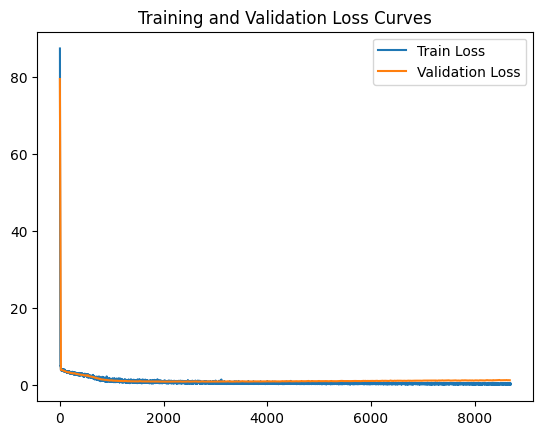

In [12]:
plt.plot([x[0] for x in train_losses], [x[1] for x in train_losses], label='Train Loss')
plt.plot([x[0] for x in val_losses], [x[1] for x in val_losses], label='Validation Loss')
plt.legend()
plt.title("Training and Validation Loss Curves")
plt.savefig("loss_curves.png")
plt.show()

I should have displayed the losses on a log scale. I have attached a Tensorboard screenshot steps below with a better view.


<img src=".\\assets\\Tensorboard Screenshot.png">

In [13]:
vg_loss, wer, cer, all_preds, all_targets = trainer.final_validation()
print("Validation CTC Loss:", vg_loss)
print("Validation WER:", wer)
print("Validation CER:", cer)

print("Sample Predictions vs Targets:")
for pred, target in zip(all_preds, all_targets):
    print(f"Pred: {pred} | Target: {target}")

Validation CTC Loss: 1.1934256547441084
Validation WER: 0.2542258282623394
Validation CER: 0.12731411229135053
Sample Predictions vs Targets:
Pred: rrio | Target: rio
Pred: uxor | Target: uxor
Pred: madre | Target: madre
Pred: en | Target: en
Pred: coniengado | Target: comenzado
Pred: texados, | Target: texados,
Pred: calificada, | Target: calificada,
Pred: fuese | Target: fuese
Pred: la | Target: la
Pred: que | Target: que
Pred: ses | Target: his
Pred: conte | Target: conte
Pred: bendecirles, | Target: bendecirles,
Pred: en | Target: en
Pred: la | Target: la
Pred: Valero, | Target: Valero,


I introduced character accuracy as a metric after training the final model. That is why it doesn't appear here.
Please use the validation cell below instead of the above one.

In [11]:
num_classes = len(dataset.char_to_idx) + 1  # +1 for CTC blank token
model = CRNNModel(num_classes=num_classes)
model.load_state_dict(torch.load("CRNNmodel.pth", map_location=device)) 
model.to(device)
trainer = CRNNTrainer(model, train_loader, val_loader, BLANK_IDX, idx_to_label, device)

In [12]:
vg_loss, wer, cer, acc, all_preds, all_targets = trainer.final_validation()
print("Validation CTC Loss:", vg_loss)
print("Validation WER:", wer)
print("Validation CER:", cer)
print("Validation Accuracy:", acc)

print("Sample Predictions vs Targets:")
for pred, target in zip(all_preds, all_targets):
    print(f"Pred: {pred} | Target: {target}")

Validation CTC Loss: 1.1918846343954403
Validation WER: 0.26436781609195403
Validation CER: 0.13050075872534142
Validation Accuracy: 0.8816101026045777
Sample Predictions vs Targets:
Pred: vio | Target: rio
Pred: uxor | Target: uxor
Pred: madre | Target: madre
Pred: en | Target: en
Pred: comiengado | Target: comenzado
Pred: texados, | Target: texados,
Pred: calificada, | Target: calificada,
Pred: fuese | Target: fuese
Pred: la | Target: la
Pred: que | Target: que
Pred: sies | Target: his
Pred: conte | Target: conte
Pred: bendecirles, | Target: bendecirles,
Pred: en | Target: en
Pred: le | Target: la
Pred: Valero, | Target: Valero,


Some of these metrics differ from what I got during test time because some of the operations in the network are not totally deterministic and the dataset size is extremely small. Also, the random state will have changed when I ran the notebook again because it will be the first random state without any offset from the training state, meaning the dataset transforms function is adding a different noise

In [13]:
transform = v2.Compose([
        ResizeWithPadding(32, 128),
        v2.ToTensor(),
        v2.Normalize(mean=[0.8477857112884521], std=[0.24946823716163635])
    ])
dataset.transform = transform
trainer.val_loader = test_loader
vg_loss, wer, cer, acc, all_preds, all_targets = trainer.final_validation()
print("Test CTC Loss:", vg_loss)
print("Test WER:", wer)
print("Test CER:", cer)
print("Test Accuracy:", acc)

print("Sample Predictions vs Targets:")
for pred, target in zip(all_preds, all_targets):
    print(f"Pred: {pred} | Target: {target}")

Test CTC Loss: 0.9622057974338531
Test WER: 0.22764227642276422
Test CER: 0.12072184194150591
Test Accuracy: 0.8908156711624919
Sample Predictions vs Targets:
Pred: por | Target: por
Pred: ordine | Target: ordine
Pred: hizo | Target: hizo
Pred: lo | Target: lo
Pred: muger | Target: muger
Pred: fin. | Target: sin,
Pred: de | Target: de
Pred: 4 | Target: 4.
Pred: de | Target: de
Pred: su | Target: su
Pred: resolut, | Target: resolut.
Pred: que | Target: que
Pred: Catalina, | Target: Catalina,
Pred: dieron | Target: dieron
Pred: como | Target: como
Pred: Ss | Target: Su


##### Test Accuracy = 89.08%
##### Test CER = 0.12
##### Test WER = 22.07%
##### Test CTC Loss = 0.96
These are excellent metrics considering that a very simple CRNN model was used. I am confident that the 90% accuracy requirement can be achieved by applying the ideas I mentioned earlier.